# 🔥🌿🌡️🗺️ Step 6 — Integrated Multi-Factor Fire-Risk Feature Alignment
### Combines Step 1 (Fire), Step 2 (NDVI), Step 3 (LST), Step 4 (FLDAS + land cover), Step 5 (Terrain & Accessibility), and LULC into one aligned dataset

---
**Purpose:** Steps 1-4 each produced their own per-pixel feature rasters, already
reprojected onto (or natively on) the **NDVI pipeline's grid** (3641 x 3504, EPSG:4326, 0.01
deg / ~1km):

| Step | Source | Grid status |
|---|---|---|
| 1 | Forest fire points (2000-11-01 to 2022-12-15) | Rasterized onto NDVI grid (`F10_fire_count_Step1.tif`) |
| 2 | NDVI features F1-F9 (climatology, anomaly, trend, CVSI, LISA, breakpoint) | Native NDVI grid |
| 3 | LST Day/Night/DTR (climatology, anomaly, Mann-Kendall trend, monthly) | Reprojected onto NDVI grid |
| 4 | FLDAS climatic variables (air temp, wind, precip, RH, soil moisture, net LW radiation) + ESA CCI 22-class land cover | Reprojected onto NDVI grid |
| 5a | Terrain (elevation, slope, aspect -- SRTMGL3 90m DEM) | Reprojected onto NDVI grid (`native_1km` GeoTIFFs) |
| 5b | Accessibility (distance to roads, railways, waterways -- OSM 2022) | Reprojected onto NDVI grid (`native_1km` GeoTIFFs) |
| -- | LULC forest fraction (ESA CCI / C3S, 300m, 1992-2022) | **Not yet aligned -- built and reprojected here** |

This notebook is the missing link: it builds per-pixel LULC (forest-fraction) features from the
raw 300m land-cover archive, reprojects them onto the same NDVI grid, and stacks **all six**
sources into:

1. **`Integrated_FireRisk_Stack.tif`** -- a multi-band GeoTIFF, one band per feature, all on the
   identical pixel grid (so any GIS tool or `rasterio` script can load it as one array).
2. **`Integrated_FireRisk_Pixels.parquet`** -- the same stack flattened to one row per valid
   (in-India) pixel, ready for a tabular ML model (fire occurrence as the label).
3. **`Integrated_Monthly_TimeSeries.csv`** -- national-mean NDVI + LST Day/Night + FLDAS
   climatic variables + fire counts, joined on `(year, month)`, for time-series-side analysis.

**Terrain & Accessibility wiring (added 2026-08-20):** Step 5a/5b's 6 bands (elevation,
slope, aspect, distance to roads/railways/waterways) were built and reprojected onto this
exact NDVI grid in their own notebooks -- this notebook only loads and stacks them (same
hard shape-equality-assertion pattern as every other pre-aligned source; no reprojection
happens here for these 6 bands). This closes the last gap in Biswas et al. (2025)'s 15
predictor variables: all 15 are now present in the ML-ready pixel table, not just built in
separate repos.

**Next step (Step 7+):** load `Integrated_FireRisk_Pixels.parquet` directly into a classifier /
susceptibility model -- every column is already numeric, aligned, and on one grid.

---

## 📦 Step 0 — Install Required Libraries

Run once. Pure CPU/rasterio work -- no GPU packages needed for this notebook.

In [1]:
import subprocess, sys

# Pinned to versions validated together in the Step 3 LST notebook's environment --
# numpy 2.x requires pandas >= 3.0 and matplotlib >= 3.10 (older wheels are built
# against the numpy 1.x ABI and crash with "numpy.core._multiarray_umath failed to
# import" if numpy 2.x is already present). Re-running this cell will not drift to
# incompatible versions like an unpinned "pip install numpy pandas matplotlib" would.
packages = [
    "numpy==2.5.1",
    "pandas>=3.0",
    "matplotlib>=3.10",
    "geopandas",
    "tqdm",
    "rasterio",
    "pyogrio",
    "netCDF4",
    "pyarrow",  # parquet support
]

for pkg in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    except subprocess.CalledProcessError as e:
        print(f"WARNING: failed to install {pkg} ({e}) -- continuing")

print("Library installation complete.")

Library installation complete.


## 📚 Step 1 — Imports

No GPU needed here -- every layer in this notebook is a single ~13M-pixel array (a
handful of MB each), not a multi-decade spatiotemporal stack, so plain NumPy/rasterio is
already fast.

In [2]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
import netCDF4 as nc_lib
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


## ⚙️ Step 2 — Configuration
> Edit only this cell if your file names/paths differ.

In [3]:
# ═══════════════════════════════════════════════════════════════
#  CONFIGURE PATHS — outputs of Steps 1-5, plus the raw LULC archive
# ═══════════════════════════════════════════════════════════════
BASE_DIR = r"D:\FOREST FIRE MAPPING(INDIA)"

# Step 2 -- NDVI (this pipeline's own output grid is the reference grid for everything)
NDVI_DIR = os.path.join(BASE_DIR, "NDVI_DATA_INDIA_")
NDVI_OUT_DIR = os.path.join(NDVI_DIR, "NDVI_Fire_Susceptibility_Outputs")
NDVI_RAW_DIR = os.path.join(NDVI_DIR, "NDVI TIF File_INDIA")

# Step 3 -- LST (already reprojected onto the NDVI grid)
LST_DIR = os.path.join(BASE_DIR, "LST_analysis")
LST_OUT_DIR = os.path.join(LST_DIR, "LST_Outputs")
LST_ALIGNED_DIR = os.path.join(LST_OUT_DIR, "NDVI_Aligned_GeoTIFFs")
LST_MONTHLY_CSV = os.path.join(LST_OUT_DIR, "LST_monthly_statistics_NDVI_aligned.csv")

# Step 1 -- Forest fire points + the raw LULC archive (both live under the fire folder)
FIRE_DIR = os.path.join(BASE_DIR, "Forest fire Extraction in INDIA(2000-2022)")
FIRE_CSV_PATH = os.path.join(FIRE_DIR, "Forest_Fire_Outputs", "all_forest_fires_2000_2022.csv")
LULC_DIR = os.path.join(FIRE_DIR, "Forest_Fire_Outputs", "lulc_extracted")

# Step 4 -- FLDAS climatic variables (already reprojected onto the NDVI grid) + land cover
FLDAS_DIR = os.path.join(BASE_DIR,
    "FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)")
FLDAS_OUT_DIR = os.path.join(FLDAS_DIR, "FLDAS_Outputs")
FLDAS_ALIGNED_DIR = os.path.join(FLDAS_OUT_DIR, "NDVI_Aligned_GeoTIFFs")
FLDAS_MONTHLY_CSV = os.path.join(FLDAS_OUT_DIR, "FLDAS_monthly_statistics_NDVI_aligned.csv")
LANDCOVER_22CLASS_TIF = os.path.join(FLDAS_OUT_DIR, "LandCover_22Class_Fractions_2020.tif")

# Step 5a -- Terrain (elevation/slope/aspect, SRTMGL3 90m DEM, already reprojected onto the
# NDVI grid as "native_1km" GeoTIFFs). Own repo: Terrain_Elevation_Slope_Aspect_Analysis/
TERRAIN_DIR = os.path.join(BASE_DIR, "Terrain_Elevation_Slope_Aspect_Analysis")
TERRAIN_OUT_DIR = os.path.join(TERRAIN_DIR, "Terrain_Outputs")

# Step 5b -- Accessibility (distance to roads/railways/waterways, OSM 2022, already
# reprojected onto the NDVI grid). Own repo: Distance_Roads_Railways_Waterways_Analysis/
ACCESS_DIR = os.path.join(BASE_DIR, "Distance_Roads_Railways_Waterways_Analysis")
ACCESS_OUT_DIR = os.path.join(ACCESS_DIR, "Accessibility_Outputs")

# India boundary (same shapefile + CRS fix as the Step 3 LST notebook)
BOUNDARY_SHP = os.path.join(LST_DIR, "India_State_Boundary.shp")

OUTPUT_DIR = os.path.join(BASE_DIR, "Integrated_Analysis", "Integrated_Outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# LULC years for the forest-fraction features -- these three bracket the NDVI/LST
# climatology baseline (2001-2020) and add a "most recent available" snapshot, so we
# don't need to read all ~30 years of the archive.
LULC_BASELINE_YEAR = 2001
LULC_RECENT_YEAR = 2020
LULC_CURRENT_YEAR = 2022

# Study period -- matches Steps 1-3 exactly
STUDY_START_DATE = pd.Timestamp("2000-11-01")
STUDY_END_DATE = pd.Timestamp("2022-12-15")

print("Configuration loaded:")
print(f"   NDVI outputs : {NDVI_OUT_DIR}  (exists: {os.path.isdir(NDVI_OUT_DIR)})")
print(f"   LST outputs  : {LST_ALIGNED_DIR}  (exists: {os.path.isdir(LST_ALIGNED_DIR)})")
print(f"   Fire archive : {FIRE_CSV_PATH}  (exists: {os.path.exists(FIRE_CSV_PATH)})")
print(f"   LULC archive : {LULC_DIR}  (exists: {os.path.isdir(LULC_DIR)})")
print(f"   FLDAS outputs: {FLDAS_ALIGNED_DIR}  (exists: {os.path.isdir(FLDAS_ALIGNED_DIR)})")
print(f"   Land cover   : {LANDCOVER_22CLASS_TIF}  (exists: {os.path.exists(LANDCOVER_22CLASS_TIF)})")
print(f"   Terrain      : {TERRAIN_OUT_DIR}  (exists: {os.path.isdir(TERRAIN_OUT_DIR)})")
print(f"   Accessibility: {ACCESS_OUT_DIR}  (exists: {os.path.isdir(ACCESS_OUT_DIR)})")
print(f"   Boundary     : {BOUNDARY_SHP}  (exists: {os.path.exists(BOUNDARY_SHP)})")
print(f"   Outputs      : {OUTPUT_DIR}")

Configuration loaded:
   NDVI outputs : D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI_Fire_Susceptibility_Outputs  (exists: True)
   LST outputs  : D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\NDVI_Aligned_GeoTIFFs  (exists: True)
   Fire archive : D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)\Forest_Fire_Outputs\all_forest_fires_2000_2022.csv  (exists: True)
   LULC archive : D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)\Forest_Fire_Outputs\lulc_extracted  (exists: True)
   FLDAS outputs: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs  (exists: True)
   Land cover   : D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\LandCover_22Class_Fractions_2020.tif  (exists: True)
   Terrain      : D:\F

## 🌿 Step 3 — NDVI Grid Reference + Step 2 NDVI Features

Every other source in this notebook gets reprojected/loaded onto **this** grid -- the
NDVI pipeline's own output grid (3641 x 3504, EPSG:4326, 0.01 deg). Loads the NDVI
features F1-F9 (climatology, anomaly, trend, CVSI, LISA cluster, breakpoint threshold)
directly, since they're already native to this grid.

In [4]:
print("Loading the NDVI grid reference and Step 2 NDVI features...")

NDVI_REF_TIF = os.path.join(NDVI_OUT_DIR, "F1_NDVI_QA_mean.tif")
with rasterio.open(NDVI_REF_TIF) as ref:
    grid_transform = ref.transform
    grid_crs = ref.crs
    grid_shape = (ref.height, ref.width)
    grid_profile = ref.profile.copy()
H, W = grid_shape
print(f"   Reference grid: {NDVI_REF_TIF}")
print(f"   Shape: {H} x {W}  |  CRS: {grid_crs}")
print(f"   Transform: {grid_transform}")


def read_grid_tif(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        if src.shape != grid_shape:
            raise ValueError(f"{path} shape {src.shape} does not match reference grid {grid_shape}")
    return arr


ndvi_feature_files = {
    'ndvi_mean': 'F1_NDVI_QA_mean.tif',
    'ndvi_clim_june': 'F2_NDVI_climatological_June.tif',
    'ndvi_anomaly_mean': 'F3_NDVI_anomaly_mean.tif',
    'ndvi_trend_2x12ma': 'F4_NDVI_trend_2x12MA.tif',
    'ndvi_residual_mean': 'F5_NDVI_residual_mean.tif',
    'ndvi_mk_tau': 'F6_MannKendall_tau.tif',
    'ndvi_cvsi_k8': 'F7_CVSI_k8.tif',
    'ndvi_lisa_cluster': 'F8_LISA_cluster.tif',
}

features = {}
for name, fname in ndvi_feature_files.items():
    fpath = os.path.join(NDVI_OUT_DIR, fname)
    if os.path.exists(fpath):
        features[name] = read_grid_tif(fpath)
        print(f"   Loaded: {name} <- {fname}")
    else:
        print(f"   WARNING: missing {fpath}, skipping {name}")

# F9's filename bakes in the fitted breakpoint threshold, so glob for it
f9_candidates = sorted(Path(NDVI_OUT_DIR).glob("F9_NDVI_below_threshold_*.tif"))
if f9_candidates:
    features['ndvi_below_threshold'] = read_grid_tif(f9_candidates[0])
    print(f"   Loaded: ndvi_below_threshold <- {f9_candidates[0].name}")

print(f"\n{len(features)} NDVI features loaded onto the reference grid")

Loading the NDVI grid reference and Step 2 NDVI features...
   Reference grid: D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI_Fire_Susceptibility_Outputs\F1_NDVI_QA_mean.tif
   Shape: 3641 x 3504  |  CRS: EPSG:4326
   Transform: | 0.01, 0.00, 68.20|
| 0.00,-0.01, 37.09|
| 0.00, 0.00, 1.00|
   Loaded: ndvi_mean <- F1_NDVI_QA_mean.tif


   Loaded: ndvi_clim_june <- F2_NDVI_climatological_June.tif
   Loaded: ndvi_anomaly_mean <- F3_NDVI_anomaly_mean.tif


   Loaded: ndvi_trend_2x12ma <- F4_NDVI_trend_2x12MA.tif
   Loaded: ndvi_residual_mean <- F5_NDVI_residual_mean.tif


   Loaded: ndvi_mk_tau <- F6_MannKendall_tau.tif
   Loaded: ndvi_cvsi_k8 <- F7_CVSI_k8.tif


   Loaded: ndvi_lisa_cluster <- F8_LISA_cluster.tif
   Loaded: ndvi_below_threshold <- F9_NDVI_below_threshold_0.529.tif

9 NDVI features loaded onto the reference grid


## 🌡️ Step 4 — LST Features (Step 3 output, already NDVI-aligned)

The Step 3 LST notebook already reprojected its key monthly-resolution features onto
this exact NDVI grid (`LST_analysis/LST_Outputs/NDVI_Aligned_GeoTIFFs/`). No further
reprojection needed here -- just load and add to the feature dict.

In [5]:
print("Loading Step 3 LST features (already reprojected onto the NDVI grid)...")

lst_feature_files = {
    'lst_day_anomaly_mean': 'LST_Day_anomaly_mean_on_NDVI_grid.tif',
    'lst_night_anomaly_mean': 'LST_Night_anomaly_mean_on_NDVI_grid.tif',
    'dtr_anomaly_mean': 'DTR_anomaly_mean_on_NDVI_grid.tif',
    'lst_day_mk_tau_monthly': 'MannKendall_tau_LST_Day_monthly_on_NDVI_grid.tif',
    'lst_night_mk_tau_monthly': 'MannKendall_tau_LST_Night_monthly_on_NDVI_grid.tif',
}
for name, fname in lst_feature_files.items():
    fpath = os.path.join(LST_ALIGNED_DIR, fname)
    if os.path.exists(fpath):
        features[name] = read_grid_tif(fpath)
        print(f"   Loaded: {name} <- {fname}")
    else:
        print(f"   WARNING: missing {fpath}, skipping {name}")

print(f"\n{len(features)} features loaded so far (NDVI + LST)")

Loading Step 3 LST features (already reprojected onto the NDVI grid)...


   Loaded: lst_day_anomaly_mean <- LST_Day_anomaly_mean_on_NDVI_grid.tif


   Loaded: lst_night_anomaly_mean <- LST_Night_anomaly_mean_on_NDVI_grid.tif


   Loaded: dtr_anomaly_mean <- DTR_anomaly_mean_on_NDVI_grid.tif


   Loaded: lst_day_mk_tau_monthly <- MannKendall_tau_LST_Day_monthly_on_NDVI_grid.tif


   Loaded: lst_night_mk_tau_monthly <- MannKendall_tau_LST_Night_monthly_on_NDVI_grid.tif

14 features loaded so far (NDVI + LST)


## 🌬️ Step 4b — FLDAS Climatic Variables + Land Cover 22-Class (Step 4 output, already NDVI-aligned)

The Step 4 FLDAS notebook already reprojected its 6 climatic variables (bilinear, 0.1 deg
-> NDVI's 0.01 deg) onto this exact NDVI grid (`FLDAS_Outputs/NDVI_Aligned_GeoTIFFs/`), and
separately reclassified ESA CCI/C3S land cover into 22 base-class fractional-cover bands on
this same grid (`LandCover_22Class_Fractions_2020.tif`). No further reprojection needed --
load both and add to the feature dict, exactly as documented in Step 4's own closing note as
the intended extension point for this notebook.

In [6]:
print("Loading Step 4 FLDAS climatic features (already reprojected onto the NDVI grid)...")

fldas_feature_files = {
    'fldas_airtemp_anomaly': 'AirTemp_anomaly_mean_on_NDVI_grid.tif',
    'fldas_wind_anomaly': 'Wind_anomaly_mean_on_NDVI_grid.tif',
    'fldas_precip_anomaly': 'Precip_anomaly_mean_on_NDVI_grid.tif',
    'fldas_rh_anomaly': 'RH_anomaly_mean_on_NDVI_grid.tif',
    'fldas_soilmoisture_anomaly': 'SoilMoisture_anomaly_mean_on_NDVI_grid.tif',
    'fldas_netlwradiation_anomaly': 'NetLWRadiation_anomaly_mean_on_NDVI_grid.tif',
    'fldas_airtemp_mk_tau_monthly': 'MannKendall_tau_AirTemp_monthly_on_NDVI_grid.tif',
    'fldas_wind_mk_tau_monthly': 'MannKendall_tau_Wind_monthly_on_NDVI_grid.tif',
    'fldas_precip_mk_tau_monthly': 'MannKendall_tau_Precip_monthly_on_NDVI_grid.tif',
    'fldas_rh_mk_tau_monthly': 'MannKendall_tau_RH_monthly_on_NDVI_grid.tif',
    'fldas_soilmoisture_mk_tau_monthly': 'MannKendall_tau_SoilMoisture_monthly_on_NDVI_grid.tif',
    'fldas_netlwradiation_mk_tau_monthly': 'MannKendall_tau_NetLWRadiation_monthly_on_NDVI_grid.tif',
}
for name, fname in fldas_feature_files.items():
    fpath = os.path.join(FLDAS_ALIGNED_DIR, fname)
    if os.path.exists(fpath):
        features[name] = read_grid_tif(fpath)
        print(f"   Loaded: {name} <- {fname}")
    else:
        print(f"   WARNING: missing {fpath}, skipping {name}")

print(f"\n{len(features)} features loaded so far (NDVI + LST + FLDAS)")

print("\nLoading Step 4 land cover 22-class fractional-cover bands...")
if os.path.exists(LANDCOVER_22CLASS_TIF):
    with rasterio.open(LANDCOVER_22CLASS_TIF) as src:
        if (src.height, src.width) != grid_shape:
            raise ValueError(
                f"{LANDCOVER_22CLASS_TIF} shape {src.shape} does not match reference grid {grid_shape}"
            )
        band_descriptions = src.descriptions
        for band_idx, band_name in enumerate(band_descriptions, start=1):
            features[f"landcover_frac_{band_name}"] = src.read(band_idx).astype(np.float32)
    print(f"   Loaded {len(band_descriptions)} land-cover class fractions from "
          f"{os.path.basename(LANDCOVER_22CLASS_TIF)}")
else:
    print(f"   WARNING: missing {LANDCOVER_22CLASS_TIF}, skipping land cover 22-class features")

print(f"\n{len(features)} features loaded so far (NDVI + LST + FLDAS + land cover)")

Loading Step 4 FLDAS climatic features (already reprojected onto the NDVI grid)...


   Loaded: fldas_airtemp_anomaly <- AirTemp_anomaly_mean_on_NDVI_grid.tif


   Loaded: fldas_wind_anomaly <- Wind_anomaly_mean_on_NDVI_grid.tif


   Loaded: fldas_precip_anomaly <- Precip_anomaly_mean_on_NDVI_grid.tif


   Loaded: fldas_rh_anomaly <- RH_anomaly_mean_on_NDVI_grid.tif


...

   Loaded: fldas_precip_mk_tau_monthly <- MannKendall_tau_Precip_monthly_on_NDVI_grid.tif


   Loaded: fldas_rh_mk_tau_monthly <- MannKendall_tau_RH_monthly_on_NDVI_grid.tif


   Loaded: fldas_soilmoisture_mk_tau_monthly <- MannKendall_tau_SoilMoisture_monthly_on_NDVI_grid.tif


   Loaded: fldas_netlwradiation_mk_tau_monthly <- MannKendall_tau_NetLWRadiation_monthly_on_NDVI_grid.tif

26 features loaded so far (NDVI + LST + FLDAS)

Loading Step 4 land cover 22-class fractional-cover bands...


   Loaded 22 land-cover class fractions from LandCover_22Class_Fractions_2020.tif

48 features loaded so far (NDVI + LST + FLDAS + land cover)


## ⛰️🛣️ Step 4c — Terrain & Accessibility Features (Step 5a/5b output, already NDVI-aligned)

The Step 5a Terrain notebook (`Terrain_Elevation_Slope_Aspect_Analysis/`) and Step 5b
Accessibility notebook (`Distance_Roads_Railways_Waterways_Analysis/`) already reprojected
their outputs onto this exact NDVI grid (`*_native_1km.tif`) -- no further reprojection
needed here, just load and add to the feature dict, following the identical
hard-shape-equality-assertion pattern (`read_grid_tif`) used for every other pre-aligned
source in this notebook. These 6 bands close the last 6 of Biswas et al. (2025)'s 15
predictor variables, bringing this pipeline's ML-ready feature table to full 15/15 parity
with the reference paper (the terrain/accessibility work itself existed since 2026-08-18,
but was not wired into the pixel table until now). The categorical
`T3b_Aspect_8class_native_1km.tif` is intentionally **not** loaded here -- it's redundant
with the continuous `T3_Aspect_native_1km.tif` already included.

In [7]:
print("Loading Step 5a/5b terrain + accessibility features (already reprojected onto the NDVI grid)...")

terrain_access_feature_files = {
    'terrain_elevation': (TERRAIN_OUT_DIR, 'T1_Elevation_native_1km.tif'),
    'terrain_slope': (TERRAIN_OUT_DIR, 'T2_Slope_native_1km.tif'),
    'terrain_aspect': (TERRAIN_OUT_DIR, 'T3_Aspect_native_1km.tif'),
    'access_dist_roads': (ACCESS_OUT_DIR, 'D1_Distance_to_Roads_native_1km.tif'),
    'access_dist_railways': (ACCESS_OUT_DIR, 'D2_Distance_to_Railways_native_1km.tif'),
    'access_dist_waterways': (ACCESS_OUT_DIR, 'D3_Distance_to_Waterways_native_1km.tif'),
}
for name, (src_dir, fname) in terrain_access_feature_files.items():
    fpath = os.path.join(src_dir, fname)
    if os.path.exists(fpath):
        # read_grid_tif raises ValueError on a shape mismatch against the NDVI reference
        # grid -- same hard assertion as every other pre-aligned source, no silent resample.
        features[name] = read_grid_tif(fpath)
        print(f"   Loaded: {name} <- {fname}")
    else:
        print(f"   WARNING: missing {fpath}, skipping {name}")

print(f"\n{len(features)} features loaded so far (NDVI + LST + FLDAS + land cover + terrain + accessibility)")

Loading Step 5a/5b terrain + accessibility features (already reprojected onto the NDVI grid)...
   Loaded: terrain_elevation <- T1_Elevation_native_1km.tif
   Loaded: terrain_slope <- T2_Slope_native_1km.tif


   Loaded: terrain_aspect <- T3_Aspect_native_1km.tif
   Loaded: access_dist_roads <- D1_Distance_to_Roads_native_1km.tif
   Loaded: access_dist_railways <- D2_Distance_to_Railways_native_1km.tif


   Loaded: access_dist_waterways <- D3_Distance_to_Waterways_native_1km.tif

54 features loaded so far (NDVI + LST + FLDAS + land cover + terrain + accessibility)


## 🔥 Step 5 — Fire Feature (Step 1 output, reused as-is)

The NDVI pipeline already rasterized Step 1's fire points onto this exact grid
(`F10_fire_count_Step1.tif`). Reusing it here (rather than re-deriving from the raw CSV)
guarantees this notebook's fire layer is identical to the one the NDVI features were
built and validated against.

In [8]:
print("Loading forest fire points (Step 1 output)...")

FIRE_COUNT_TIF = os.path.join(NDVI_OUT_DIR, 'F10_fire_count_Step1.tif')
features['fire_count'] = read_grid_tif(FIRE_COUNT_TIF)
features['fire_ever'] = (features['fire_count'] > 0).astype(np.float32)

print(f"   Loaded: fire_count <- F10_fire_count_Step1.tif  (Step 1's own rasterization, reused as-is)")
print(f"   Fire-affected pixels: {int(features['fire_ever'].sum()):,} / {H*W:,} "
      f"({100*np.nanmean(features['fire_ever']):.2f}%)")

Loading forest fire points (Step 1 output)...
   Loaded: fire_count <- F10_fire_count_Step1.tif  (Step 1's own rasterization, reused as-is)
   Fire-affected pixels: 270,655 / 12,758,064 (2.12%)


## 🗺️ Step 6 — LULC Forest-Fraction Features (the missing alignment piece)

The LULC archive (ESA CCI / C3S LCCS, 300m, 1992-2022) has never been reprojected onto
the NDVI/LST grid. This step reads three representative years -- the climatology
baseline start (2001), baseline end (2020), and most recent available (2022) -- 
reclassifies each into a binary forest mask, and **area-averages** it onto the NDVI
grid, producing a continuous 0-1 fractional forest-cover feature per pixel (far more
useful for a numeric model than a coarse land-cover code). The baseline-to-recent
difference gives a simple deforestation/forest-loss feature.

In [9]:
# ESA CCI / C3S LCCS classes counted as "forest" -- matches Step 1's own FOREST_CODES
# exactly (Forest fire Extraction in INDIA(2000-2022)/build_notebook.py), per
# Sannigrahi et al. 2018 as cited in Biswas et al. 2025 (p.4863). Reconciled 2026-08-15:
# this set previously omitted 100/110, an undocumented divergence from Step 1's
# definition -- now both the fire-point ground-truth filter (Step 1) and this
# forest-fraction predictor feature (Step 6) share one operational "forest" definition.
# Per the lccs_class variable's own flag_meanings in the NetCDF: 50,60,61,62 =
# broadleaved evergreen/deciduous; 70,71,72 = needleleaved evergreen; 80,81,82 =
# needleleaved deciduous; 90 = tree_mixed; 100 = mosaic_tree_and_shrub;
# 110 = mosaic_herbaceous.
FOREST_CODES = {50, 60, 61, 62, 70, 71, 72, 80, 81, 82, 90, 100, 110}


def find_lulc_file(year):
    candidates = sorted(Path(LULC_DIR).glob(f"*-{year}-*.nc"))
    if not candidates:
        raise FileNotFoundError(f"No LULC file found for year {year} in {LULC_DIR}")
    return candidates[0]


def load_forest_fraction(year, dst_transform, dst_crs, dst_shape):
    """
    Read one year's 300m LCCS classification, binarize to forest/non-forest, and
    resample (area-average) onto the destination (NDVI) grid -- giving a continuous
    0-1 fractional forest cover per destination pixel rather than a coarse category.
    """
    fp = find_lulc_file(year)
    with nc_lib.Dataset(fp, 'r') as ds:
        lccs = np.asarray(ds.variables['lccs_class'][0, :, :])
        lat = np.asarray(ds.variables['lat'][:])
        lon = np.asarray(ds.variables['lon'][:])

    forest_mask = np.isin(lccs, list(FOREST_CODES)).astype(np.float32)

    # Reconstruct this subset's own affine transform from its lat/lon arrays (north-up:
    # lat descending, lon ascending).
    res_lon = float(lon[1] - lon[0])
    res_lat = float(lat[0] - lat[1])
    west = float(lon[0] - res_lon / 2)
    north = float(lat[0] + res_lat / 2)
    src_transform = rasterio.transform.from_origin(west, north, res_lon, res_lat)

    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=forest_mask, destination=dst,
        src_transform=src_transform, src_crs="EPSG:4326",
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=Resampling.average,
    )
    return dst, fp.name


print(f"Building forest-fraction features from LULC ({LULC_BASELINE_YEAR}, {LULC_RECENT_YEAR}, {LULC_CURRENT_YEAR})...")

forest_baseline, f_base_name = load_forest_fraction(LULC_BASELINE_YEAR, grid_transform, grid_crs, grid_shape)
print(f"   {LULC_BASELINE_YEAR}: {f_base_name}  (mean forest cover: {np.nanmean(forest_baseline)*100:.1f}%)")

forest_recent, f_recent_name = load_forest_fraction(LULC_RECENT_YEAR, grid_transform, grid_crs, grid_shape)
print(f"   {LULC_RECENT_YEAR}: {f_recent_name}  (mean forest cover: {np.nanmean(forest_recent)*100:.1f}%)")

forest_current, f_curr_name = load_forest_fraction(LULC_CURRENT_YEAR, grid_transform, grid_crs, grid_shape)
print(f"   {LULC_CURRENT_YEAR}: {f_curr_name}  (mean forest cover: {np.nanmean(forest_current)*100:.1f}%)")

features['forest_frac_baseline'] = forest_baseline
features['forest_frac_recent'] = forest_recent
features['forest_frac_current'] = forest_current
features['forest_loss_baseline_to_recent'] = forest_baseline - forest_recent

print(f"\n{len(features)} features loaded so far (NDVI + LST + Fire + LULC)")

Building forest-fraction features from LULC (2001, 2020, 2022)...


   2001: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2001-v2.0.7cds.area-subset.37.5.98.6.67.5.nc  (mean forest cover: 10.2%)


   2020: C3S-LC-L4-LCCS-Map-300m-P1Y-2020-v2.1.1.area-subset.37.5.98.6.67.5.nc  (mean forest cover: 10.5%)


   2022: C3S-LC-L4-LCCS-Map-300m-P1Y-2022-v2.1.1.area-subset.37.5.98.6.67.5.nc  (mean forest cover: 10.7%)

60 features loaded so far (NDVI + LST + Fire + LULC)


## 📍 Step 7 — India Boundary Mask (Pixel Validity)

Same boundary and CRS fix as the Step 3 LST notebook (this shapefile has no `.prj`; its
coordinates are Web Mercator meters, not lon/lat). Used to restrict the flattened pixel
table to in-India pixels only.

In [10]:
print("Loading India boundary (defines which pixels are valid in the flattened table)...")

india_gdf = gpd.read_file(BOUNDARY_SHP)
# Same fix as the Step 3 LST notebook: this shapefile ships without a .prj, but its raw
# coordinates are Web Mercator meters, not lon/lat.
if india_gdf.crs is None:
    india_gdf = india_gdf.set_crs("EPSG:3857", allow_override=True)
india_gdf = india_gdf.to_crs("EPSG:4326")
india_geom = india_gdf.dissolve(by=None).geometry.iloc[0]

india_mask = rasterize(
    [(india_geom, 1)], out_shape=grid_shape, transform=grid_transform, fill=0, dtype=np.uint8
).astype(bool)
print(f"   India mask: {int(india_mask.sum()):,} / {H*W:,} px ({100*india_mask.sum()/(H*W):.1f}%)")

Loading India boundary (defines which pixels are valid in the flattened table)...


   India mask: 4,184,671 / 12,758,064 px (32.8%)


## 💾 Step 8 — Assemble & Export the Integrated Spatial Feature Stack

Stacks every feature loaded so far (NDVI + LST + fire + LULC) into one array, exports a
multi-band GeoTIFF, and flattens it to a per-pixel table restricted to valid in-India
pixels -- the direct input for a tabular fire-susceptibility model.

In [11]:
print("Assembling the integrated feature stack...")

feature_names = list(features.keys())
print(f"   {len(feature_names)} feature layers: {feature_names}")

stack = np.stack([features[name] for name in feature_names], axis=0)  # (n_features, H, W)

# ---- 1. Multi-band GeoTIFF: one band per feature, all on the NDVI grid ----
stack_profile = grid_profile.copy()
stack_profile.update(count=len(feature_names), dtype='float32', nodata=np.nan, compress='lzw')
stack_path = os.path.join(OUTPUT_DIR, "Integrated_FireRisk_Stack.tif")
with rasterio.open(stack_path, 'w', **stack_profile) as dst:
    for i, name in enumerate(feature_names):
        dst.write(stack[i].astype(np.float32), i + 1)
        dst.set_band_description(i + 1, name)
print(f"   Saved: {stack_path}")

# ---- 2. Flattened per-pixel table (in-India, NDVI-valid pixels only) ----
valid = india_mask & ~np.isnan(features['ndvi_mean'])
rows, cols = np.where(valid)
print(f"   Valid in-India pixels: {len(rows):,} / {H*W:,} ({100*len(rows)/(H*W):.1f}%)")

xs, ys = rasterio.transform.xy(grid_transform, rows, cols)
df_pixels = pd.DataFrame({'lon': xs, 'lat': ys})
for i, name in enumerate(feature_names):
    df_pixels[name] = stack[i][rows, cols]

pixels_path = os.path.join(OUTPUT_DIR, "Integrated_FireRisk_Pixels.parquet")
df_pixels.to_parquet(pixels_path, index=False)
print(f"   Saved: {pixels_path}  ({len(df_pixels):,} rows x {len(df_pixels.columns)} columns)")

csv_sample_path = os.path.join(OUTPUT_DIR, "Integrated_FireRisk_Pixels_sample200k.csv")
df_pixels.sample(min(200_000, len(df_pixels)), random_state=42).to_csv(csv_sample_path, index=False)
print(f"   Saved (200k-row sample, for tools without parquet support): {csv_sample_path}")

print(f"\nIntegrated spatial feature stack ready: {len(feature_names)} layers x {len(df_pixels):,} valid pixels")

Assembling the integrated feature stack...
   60 feature layers: ['ndvi_mean', 'ndvi_clim_june', 'ndvi_anomaly_mean', 'ndvi_trend_2x12ma', 'ndvi_residual_mean', 'ndvi_mk_tau', 'ndvi_cvsi_k8', 'ndvi_lisa_cluster', 'ndvi_below_threshold', 'lst_day_anomaly_mean', 'lst_night_anomaly_mean', 'dtr_anomaly_mean', 'lst_day_mk_tau_monthly', 'lst_night_mk_tau_monthly', 'fldas_airtemp_anomaly', 'fldas_wind_anomaly', 'fldas_precip_anomaly', 'fldas_rh_anomaly', 'fldas_soilmoisture_anomaly', 'fldas_netlwradiation_anomaly', 'fldas_airtemp_mk_tau_monthly', 'fldas_wind_mk_tau_monthly', 'fldas_precip_mk_tau_monthly', 'fldas_rh_mk_tau_monthly', 'fldas_soilmoisture_mk_tau_monthly', 'fldas_netlwradiation_mk_tau_monthly', 'landcover_frac_LC22_10_cropland_rainfed', 'landcover_frac_LC22_20_cropland_irrigated', 'landcover_frac_LC22_30_mosaic_cropland', 'landcover_frac_LC22_40_mosaic_natural_vegetation', 'landcover_frac_LC22_50_tree_broadleaved_evergreen', 'landcover_frac_LC22_60_tree_broadleaved_deciduous', 'la

   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Integrated_FireRisk_Stack.tif
   Valid in-India pixels: 4,161,009 / 12,758,064 (32.6%)


   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Integrated_FireRisk_Pixels.parquet  (4,161,009 rows x 62 columns)


   Saved (200k-row sample, for tools without parquet support): D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Integrated_FireRisk_Pixels_sample200k.csv

Integrated spatial feature stack ready: 60 layers x 4,161,009 valid pixels


## 📈 Step 9 — Monthly Time-Series Alignment (Fire + LST + NDVI)

The spatial stack above collapses time into per-pixel summary statistics (means,
anomalies, trends). This step keeps the temporal axis: national-mean NDVI (computed
fresh from the monthly GeoTIFFs), joined against Step 3's own LST monthly table (which
already carries `fire_detections`), on the shared `(year, month)` key.

In [12]:
print("Building NDVI monthly national-mean series (reads each monthly NDVI GeoTIFF once)...")

date_re_ndvi = re.compile(r"doy(\d{4})(\d{3})")
ndvi_monthly_files = []
for fp in sorted(Path(NDVI_RAW_DIR).glob("*.tif")):
    if "reliability" in fp.name.lower() or "_NDVI_" not in fp.name:
        continue
    m = date_re_ndvi.search(fp.name)
    if not m:
        continue
    year, doy = int(m.group(1)), int(m.group(2))
    date = pd.Timestamp(year=year, month=1, day=1) + pd.Timedelta(days=doy - 1)
    if STUDY_START_DATE <= date <= STUDY_END_DATE:
        ndvi_monthly_files.append((date.year, date.month, fp))

ndvi_monthly_files = sorted(ndvi_monthly_files)
ndvi_monthly_rows = []
for year, month, fp in tqdm(ndvi_monthly_files, desc="Reading NDVI monthly means"):
    with rasterio.open(fp) as src:
        raw = src.read(1).astype(np.float32)
        nodata = src.nodata
    if np.nanmax(raw) > 2.0:
        raw = np.where((raw >= -2000) & (raw <= 10000), raw * 0.0001, np.nan)
    elif nodata is not None:
        raw = np.where(raw == nodata, np.nan, raw)
    valid_ndvi = np.where((raw >= -0.2) & (raw <= 1.0), raw, np.nan)
    ndvi_monthly_rows.append({'year': year, 'month': month, 'ndvi_mean': float(np.nanmean(valid_ndvi))})

df_ndvi_monthly = pd.DataFrame(ndvi_monthly_rows)
first_y, first_m = ndvi_monthly_files[0][0], ndvi_monthly_files[0][1]
last_y, last_m = ndvi_monthly_files[-1][0], ndvi_monthly_files[-1][1]
print(f"   {len(df_ndvi_monthly)} NDVI monthly means computed ({first_y}-{first_m:02d} to {last_y}-{last_m:02d})")

print("\nMerging with the Step 3 LST monthly table (which already carries fire_detections)...")
df_lst_monthly = pd.read_csv(LST_MONTHLY_CSV)

df_integrated_monthly = df_lst_monthly.merge(df_ndvi_monthly, on=['year', 'month'], how='outer')

print("\nMerging with the Step 4 FLDAS monthly table (climatic variables)...")
if os.path.exists(FLDAS_MONTHLY_CSV):
    df_fldas_monthly = pd.read_csv(FLDAS_MONTHLY_CSV)
    # fire_detections/fire_count already carried from the LST table -- drop FLDAS's own
    # copy of the same column (identical source: Step 1) to avoid a _x/_y collision.
    fldas_drop_cols = [c for c in df_fldas_monthly.columns
                        if c in df_integrated_monthly.columns and c not in ('year', 'month')]
    if fldas_drop_cols:
        df_fldas_monthly = df_fldas_monthly.drop(columns=fldas_drop_cols)
    df_integrated_monthly = df_integrated_monthly.merge(df_fldas_monthly, on=['year', 'month'], how='outer')
    print(f"   Merged {len(df_fldas_monthly.columns) - 2} FLDAS columns")
else:
    print(f"   WARNING: missing {FLDAS_MONTHLY_CSV}, skipping FLDAS monthly merge")

df_integrated_monthly = df_integrated_monthly.sort_values(['year', 'month']).reset_index(drop=True)

monthly_path = os.path.join(OUTPUT_DIR, "Integrated_Monthly_TimeSeries.csv")
df_integrated_monthly.to_csv(monthly_path, index=False)
print(f"   Saved: {monthly_path}  ({len(df_integrated_monthly)} months x {len(df_integrated_monthly.columns)} columns)")
print(f"   Columns: {df_integrated_monthly.columns.tolist()}")

Building NDVI monthly national-mean series (reads each monthly NDVI GeoTIFF once)...


Reading NDVI monthly means:   0%|          | 0/266 [00:00<?, ?it/s]

Reading NDVI monthly means:   0%|          | 1/266 [00:00<01:01,  4.28it/s]

Reading NDVI monthly means:   1%|          | 2/266 [00:00<00:57,  4.57it/s]

Reading NDVI monthly means:   1%|          | 3/266 [00:00<00:56,  4.66it/s]

...

Reading NDVI monthly means:  99%|█████████▉| 264/266 [01:00<00:00,  4.59it/s]

Reading NDVI monthly means: 100%|█████████▉| 265/266 [01:00<00:00,  4.62it/s]

Reading NDVI monthly means: 100%|██████████| 266/266 [01:01<00:00,  4.56it/s]

Reading NDVI monthly means: 100%|██████████| 266/266 [01:01<00:00,  4.36it/s]

   266 NDVI monthly means computed (2000-11 to 2022-12)

Merging with the Step 3 LST monthly table (which already carries fire_detections)...

Merging with the Step 4 FLDAS monthly table (climatic variables)...
   Merged 15 FLDAS columns
   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Integrated_Monthly_TimeSeries.csv  (266 months x 25 columns)
   Columns: ['year', 'month', 'lst_day_mean', 'lst_night_mean', 'dtr_mean', 'lst_day_anom_mean', 'lst_night_anom_mean', 'dtr_anom_mean', 'fire_detections', 'ndvi_mean', 'wind_mean', 'precip_mm_mean', 'precip_mmh_mean', 'rh_mean', 'tair_k_mean', 'qair_kgkg_mean', 'lwnet_wm2_mean', 'soilm_surface_kgm2_mean', 'soilm_total_kgm2_mean', 'wind_anom_mean', 'precip_anom_mean', 'rh_anom_mean', 'tair_anom_mean', 'lwnet_anom_mean', 'soilm_surface_anom_mean']


## 🗺️ Step 10 — Visualize Alignment: Correlation Matrix + Fire vs Non-Fire Distributions

A quick sanity check that the aligned sources actually carry distinct, meaningful
signal: a per-pixel correlation matrix across all features, and a comparison of each
feature's distribution at fire-affected vs unaffected pixels.

Generating correlation heatmap and fire-vs-non-fire comparison...


   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Feature_Correlation_Matrix.png


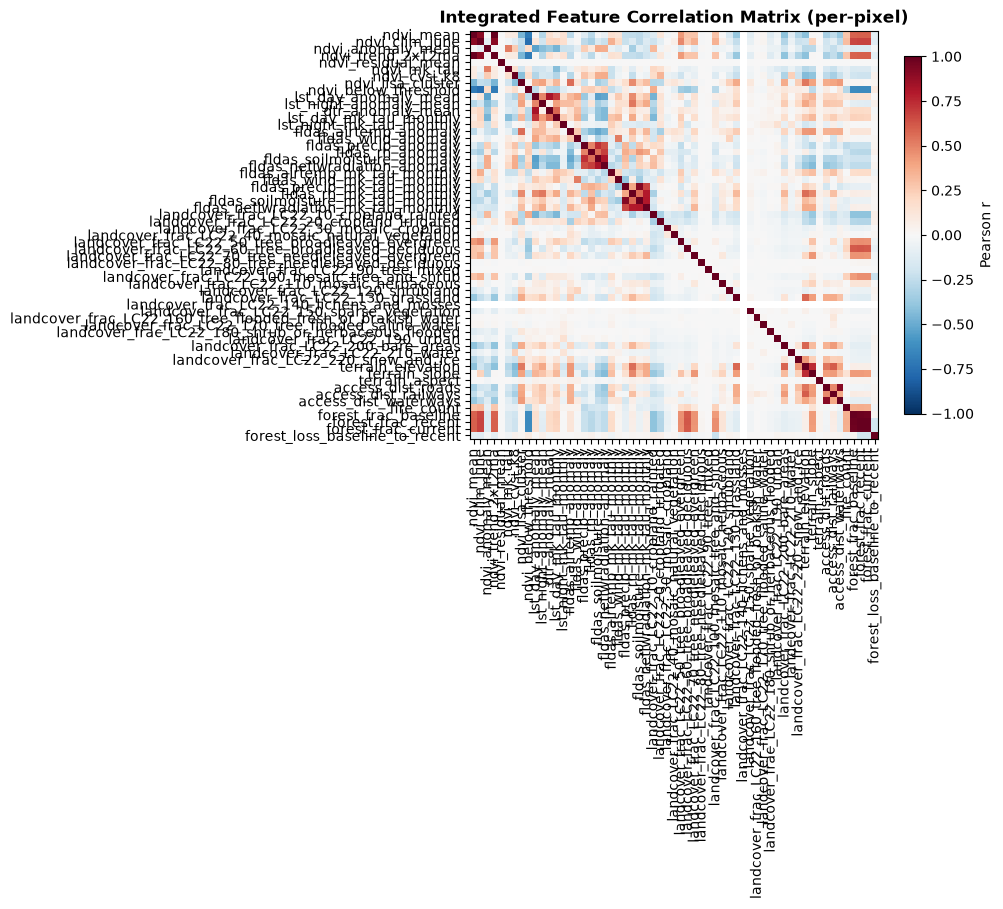

   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Fire_vs_NoFire_Feature_Distributions.png


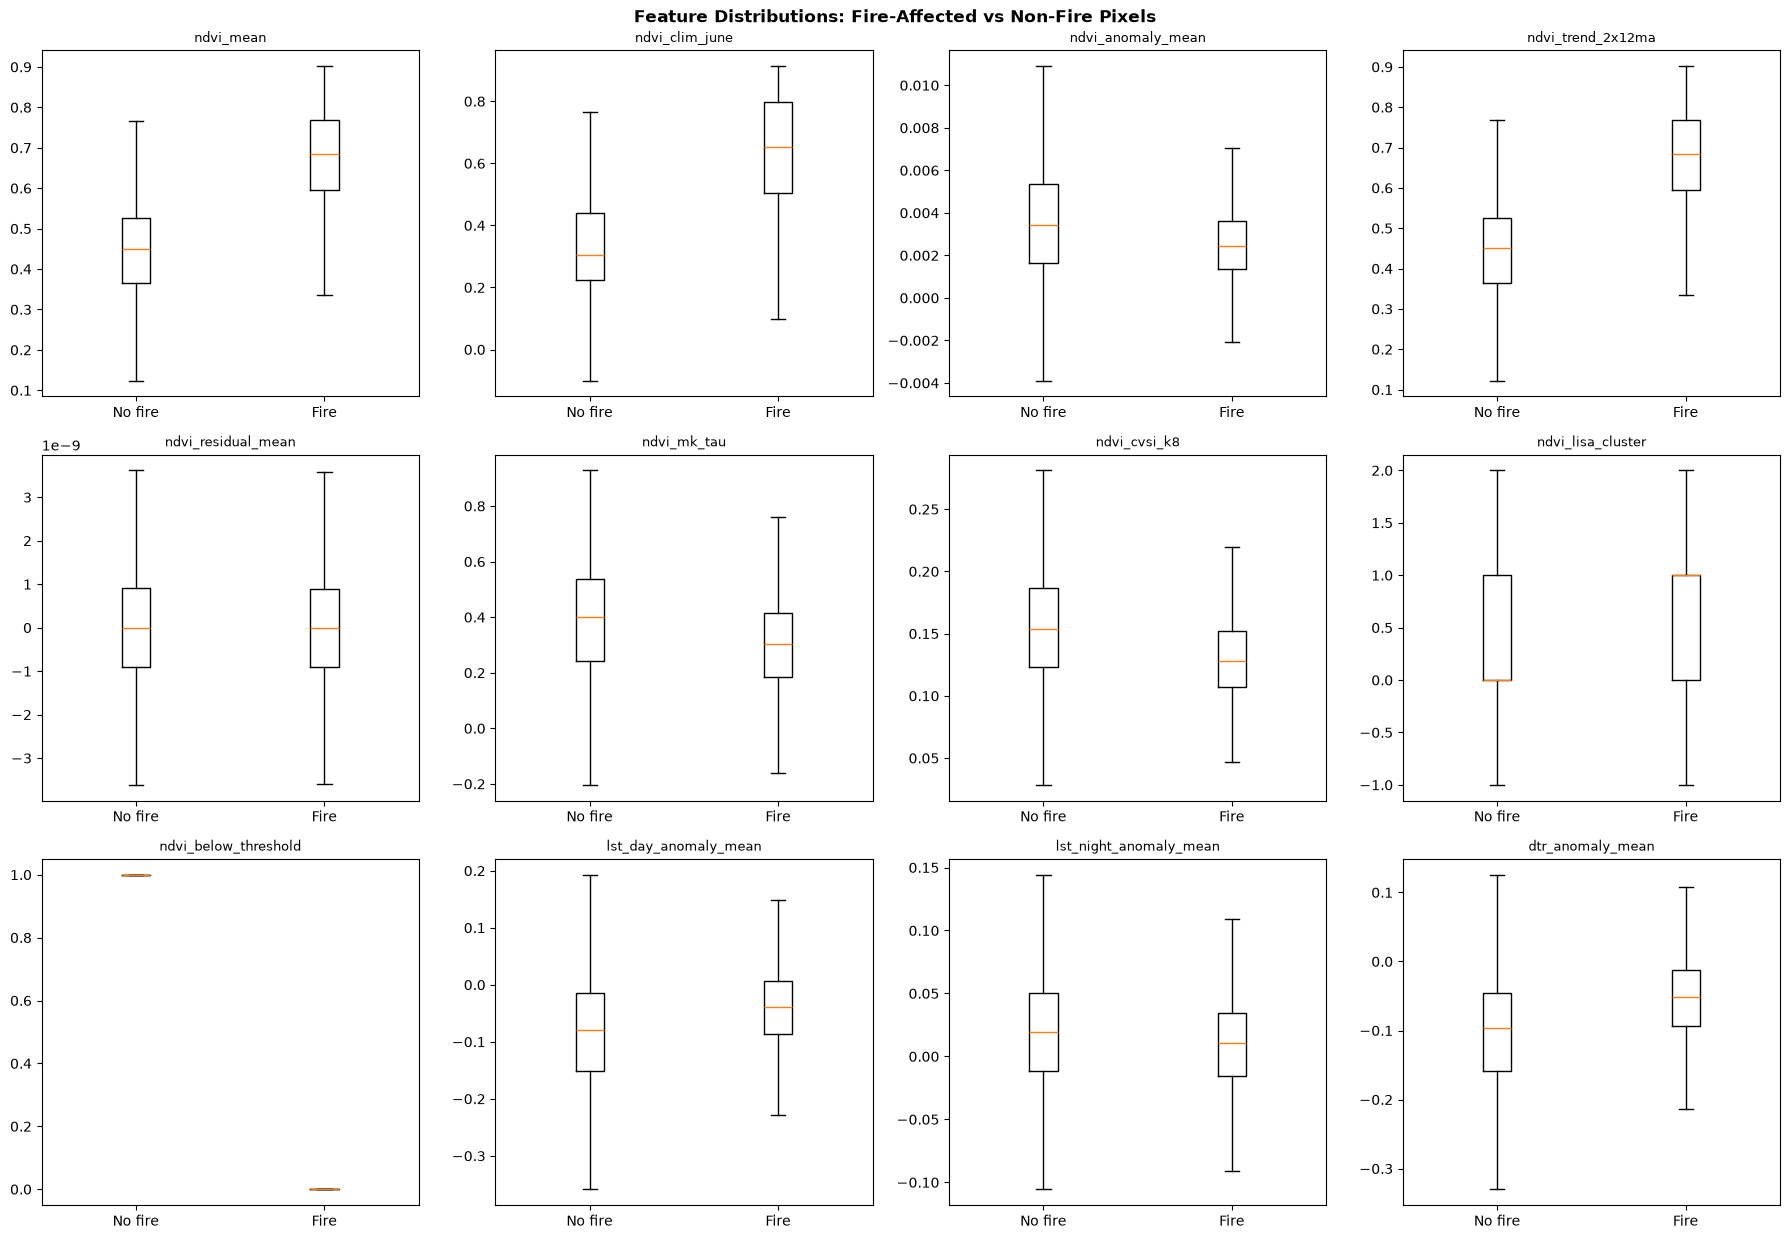


Visualizations complete


In [13]:
print("Generating correlation heatmap and fire-vs-non-fire comparison...")

corr_cols = [c for c in feature_names if c != 'fire_ever']
corr = df_pixels[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=90)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)
ax.set_title('Integrated Feature Correlation Matrix (per-pixel)', fontweight='bold')
plt.tight_layout()
outfile = os.path.join(OUTPUT_DIR, 'Feature_Correlation_Matrix.png')
plt.savefig(outfile, dpi=150, bbox_inches='tight')
print(f"   Saved: {outfile}")
plt.show()

fire_mask_px = df_pixels['fire_ever'] > 0
show_cols = corr_cols[:12]
n_rows = (len(show_cols) + 3) // 4
fig2, axes2 = plt.subplots(n_rows, 4, figsize=(18, 4.2 * n_rows))
for ax, col in zip(np.asarray(axes2).flat, show_cols):
    data_fire = df_pixels.loc[fire_mask_px, col].dropna()
    data_nofire = df_pixels.loc[~fire_mask_px, col].dropna()
    ax.boxplot([data_nofire, data_fire], tick_labels=['No fire', 'Fire'], showfliers=False)
    ax.set_title(col, fontsize=9)
for ax in np.asarray(axes2).flat[len(show_cols):]:
    ax.axis('off')
plt.suptitle('Feature Distributions: Fire-Affected vs Non-Fire Pixels', fontweight='bold')
plt.tight_layout()
outfile2 = os.path.join(OUTPUT_DIR, 'Fire_vs_NoFire_Feature_Distributions.png')
plt.savefig(outfile2, dpi=150, bbox_inches='tight')
print(f"   Saved: {outfile2}")
plt.show()

print("\nVisualizations complete")

## ✅ Step 6 Complete — Alignment Summary

**Outputs** (in `Integrated_Analysis/Integrated_Outputs/`):

| File | Contents |
|---|---|
| `Integrated_FireRisk_Stack.tif` | Multi-band GeoTIFF, one band per feature (NDVI + LST + FLDAS + land cover + terrain + accessibility + fire + LULC), all on the NDVI grid |
| `Integrated_FireRisk_Pixels.parquet` | One row per in-India pixel, all feature columns + lat/lon -- the ML-ready table |
| `Integrated_FireRisk_Pixels_sample200k.csv` | 200k-row random sample of the same table, for tools without parquet support |
| `Integrated_Monthly_TimeSeries.csv` | NDVI + LST Day/Night + FLDAS climatic variables + fire counts, joined on `(year, month)` |
| `Feature_Correlation_Matrix.png` | Sanity check: how the sources relate to each other, per pixel |
| `Fire_vs_NoFire_Feature_Distributions.png` | Does each feature actually separate fire-affected from unaffected pixels? |

**Column provenance** (for `Integrated_FireRisk_Pixels.parquet`):
- `ndvi_*` -- Step 2 NDVI pipeline (climatology, anomaly, Mann-Kendall trend, CVSI, LISA cluster, breakpoint threshold)
- `lst_*`, `dtr_*` -- Step 3 LST pipeline (Day/Night anomaly, DTR anomaly, monthly Mann-Kendall trend)
- `fldas_*` -- Step 4 FLDAS pipeline (air temp, wind, precip, RH, soil moisture, net LW radiation -- anomaly + monthly Mann-Kendall trend)
- `landcover_frac_*` -- Step 4 FLDAS pipeline (ESA CCI/C3S 2020, 22 base LCCS class fractions per NDVI pixel)
- `terrain_*` -- Step 5a Terrain pipeline (`Terrain_Elevation_Slope_Aspect_Analysis/`): elevation, slope, aspect (SRTMGL3 90m DEM, GPU Horn's-method gradient)
- `access_*` -- Step 5b Accessibility pipeline (`Distance_Roads_Railways_Waterways_Analysis/`): Euclidean distance to roads, railways, waterways (Geofabrik OSM 2022, GPU distance transform)
- `fire_count`, `fire_ever` -- Step 1 fire archive, rasterized onto this grid
- `forest_frac_*`, `forest_loss_*` -- LULC (ESA CCI/C3S 300m), resampled to fractional forest cover per NDVI pixel

**Biswas et al. (2025) predictor-variable parity:** with terrain + accessibility wired in
(2026-08-20), this pipeline's ML-ready feature table now genuinely covers all 15 of Biswas
et al.'s real predictor variables (previously only 9 of 15 were present in the trained
table despite the terrain/accessibility work already existing in its own separate repos
since 2026-08-18).

**Next step:** this parquet file is the direct input to a susceptibility/classification model --
`fire_ever` (or a thresholded `fire_count`) as the label, every other column as a feature, no
further alignment needed. Every documented variable source (NDVI, LST, FLDAS climatic
variables, land cover, terrain, accessibility) is now wired in; if a genuinely new variable
source appears later, follow the same pattern: reproject onto `grid_transform`/`grid_crs`/
`grid_shape` from this notebook's Step 3 (or confirm it's already reprojected there, like
Step 5a/5b were), then append a column to `df_pixels` before re-exporting.